# 让任意滤波器都能以并行形式组成希尔伯特滤波器

## 核心思路

任意实系数 IIR 半带滤波器（低通，通带 $[-\pi/2, \pi/2]$）可以分解为**一阶复数节的并行形式**（留数分解）：

$$
H(z) = d + \sum_{i=1}^{N} \frac{r_i}{1 - p_i z^{-1}}
$$

其中极点和留数总是以**共轭对**形式出现：$(p_i, \bar{p}_i)$、$(r_i, \bar{r}_i)$。

通过频率偏移 $z \to -jz$（即 $z^{-1} \to jz^{-1}$），可以将这个半带滤波器转换为**希尔伯特变压器**：

$$
H_h(z) = H(-jz) = d + \sum_{i=1}^{N} \frac{r_i}{1 - j p_i z^{-1}}
$$

## 目标

1. 验证并行分解的正确性（遮盖法 vs scipy）
2. 验证共轭对可合并为实数/复数二阶节
3. 观察希尔伯特变换后的频率响应和脉冲响应

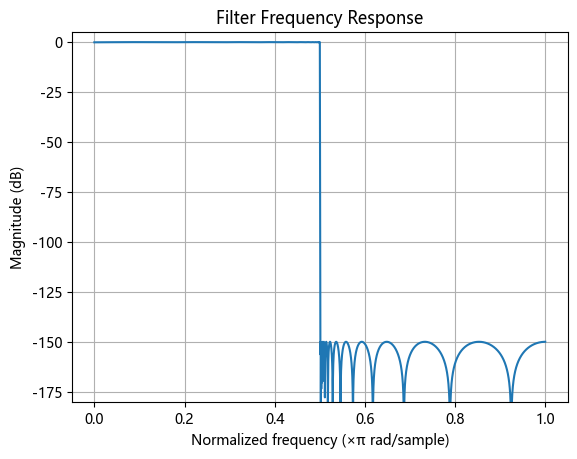

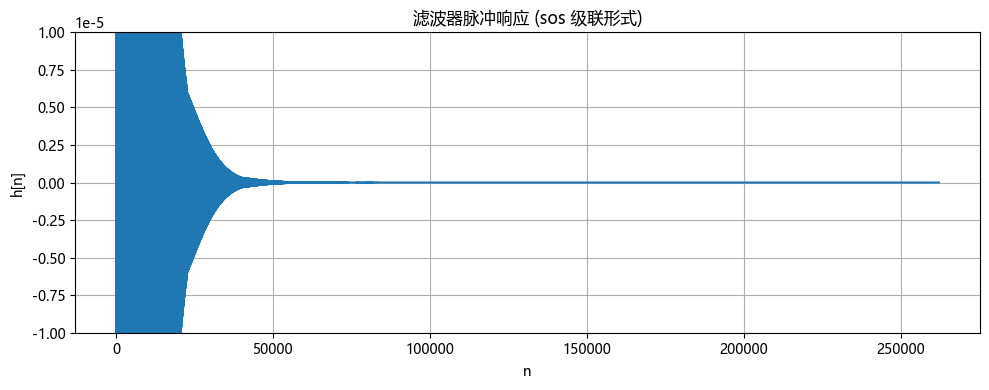

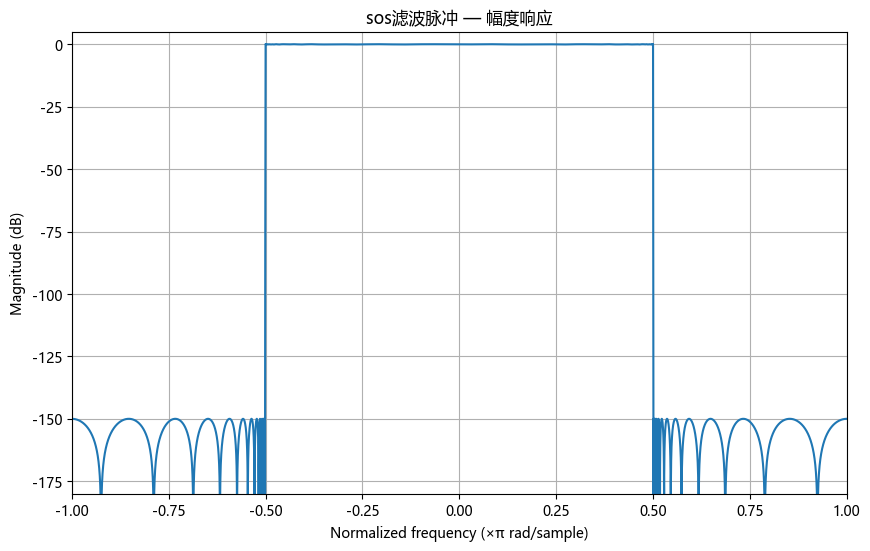

In [ ]:
import scipy.signal as signal
import numpy as np
import matplotlib.pyplot as plt

# matplotlib 中文字体配置
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "WenQuanYi Micro Hei"]
plt.rcParams["axes.unicode_minus"] = False

# 32阶切比雪夫2型低通滤波器
order = 32  # 阶数
rs = 150  # 阻带衰减 (dB)
atten = 3  # 1rad/s处的衰减(0.5采样率相当于pi/2)

if atten >= rs:
    raise RuntimeError("atten < ripple")

fscale = np.cosh(
    np.acosh(
        np.sqrt((np.pow(10.0, rs / 10.0) - 1.0) / (np.pow(10.0, atten / 10.0) - 1.0))
    )
    / (order)
)
w = np.atan(fscale) / (2 * np.pi)

# 使用二阶节形式 (sos) 保证数值稳定性
# sos = signal.cheby2(order, rs, w, fs=0.5, output='sos')
# zpk = signal.cheby2(order, rs, w, fs=0.5, output='zpk')
sos = signal.ellip(order, 0.1, rs, 0.5, fs=2, output="sos")
zpk = signal.ellip(order, 0.1, rs, 0.5, fs=2, output="zpk")
# sos = signal.cheby1(order, 0.1, 0.5, fs=0.5, output='sos')
# zpk = signal.cheby1(order, 0.1, 0.5, fs=0.5, output='zpk')

# ===== 频率响应 =====
w, h = signal.sosfreqz(sos, worN=4096)
plt.figure()
plt.plot(w / np.pi, 20 * np.log10(np.abs(h)))
plt.title("Filter Frequency Response")
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.ylim(-180, 5)
plt.show()

# ===== 脉冲响应 =====
impulse = np.zeros(2**18)
impulse[0] = 1.0
h_imp = signal.sosfilt(sos, impulse)

plt.figure(figsize=(10, 4))
plt.plot(np.arange(len(h_imp)), h_imp)
plt.title("滤波器脉冲响应 (sos 级联形式)")
plt.xlabel("n")
plt.ylabel("h[n]")
plt.ylim(-1e-5, 1e-5)
plt.grid()
plt.tight_layout()
plt.show()

# FFT → 幅度响应
H = np.fft.fft(h_imp)
H = np.fft.fftshift(H)
w_axis = np.fft.fftshift(np.fft.fftfreq(len(h_imp))) * 2 * np.pi

mag_db = 20 * np.log10(np.abs(H) + 1e-15)

plt.figure(figsize=(10, 6))
plt.plot(w_axis / np.pi, mag_db)
plt.title("sos滤波脉冲 — 幅度响应")
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.ylim(-180, 5)
plt.xlim(-1, 1)
plt.show()

## scipy 自带的留数法转换到并行形式

将 SOS（级联二阶节）转换为**传输函数多项式** $H(z) = B(z)/A(z)$，然后调用 `scipy.signal.residuez` 得到：

$$
H(z) = d + \sum_{i=1}^{N} \frac{r_i}{1 - p_i z^{-1}}
$$

其中 $r_i$ 为留数，$p_i$ 为极点，$d$ 为直接项。

### 实数二阶节合并

由于极点和留数为共轭对 $(p, \bar{p}), (r, \bar{r})$，可以将每对合并为实数二阶节：

$$
\frac{r}{1 - p z^{-1}} + \frac{\bar{r}}{1 - \bar{p} z^{-1}}
= \frac{a + b z^{-1}}{1 + c z^{-1} + d z^{-2}}
$$

其中 $a = 2\text{Re}[r],\;\; b = -2\text{Re}[r \bar{p}],\;\; c = -2\text{Re}[p],\;\; d = |p|^2$。

> 这是最终 C++ 实现中使用的系数格式。

Partial fraction expansion (parallel form):
Residues (r):
 [ 7.55884597e-02-7.56884923e-01j  7.55884597e-02+7.56884923e-01j
 -2.00147245e-01+5.64367387e-01j -2.00147245e-01-5.64367387e-01j
  2.48870140e-01-3.24870139e-01j  2.48870140e-01+3.24870139e-01j
 -2.23165687e-01+1.39092428e-01j -2.23165685e-01-1.39092428e-01j
  1.62366736e-01-2.87341951e-02j  1.62366858e-01+2.87342003e-02j
 -6.12028299e-05+7.61116528e-05j -6.11523577e-05-7.65954861e-05j
 -1.00544763e-01-2.27501562e-02j -1.00558907e-01+2.27441115e-02j
 -4.02717787e-03+4.03675045e-03j -4.07297275e-03-4.09896874e-03j
  7.29590123e-06+2.88721968e-06j  7.30351995e-06-2.89034339e-06j
  3.77927273e-02-1.98376585e-02j  3.82152931e-02+1.98374299e-02j
 -1.12592138e-07-4.22314477e-06j -1.17455532e-07+4.21761732e-06j
  2.45024678e-03+5.03977789e-03j  2.42222171e-03-5.03288568e-03j
 -1.05554971e-06+3.97520940e-06j -1.06481030e-06-3.98573163e-06j
 -1.47975251e-04+1.58893488e-04j -1.48705134e-04-1.59042116e-04j
 -4.91630332e-06-4.16380320e-06

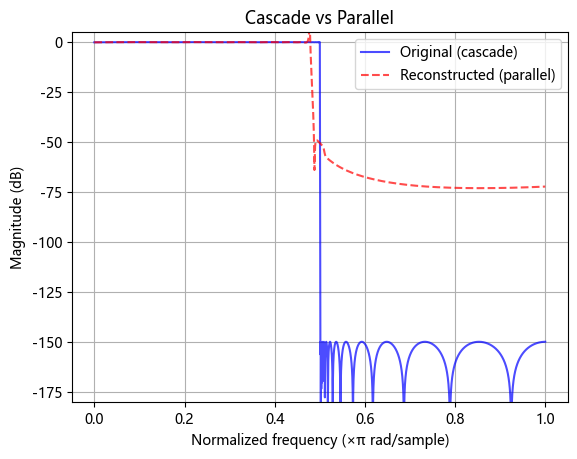

In [ ]:
# Convert cascade (series) filter to parallel form using partial fraction expansion
# First, convert SOS to transfer function polynomials
b, a = signal.sos2tf(sos)

# Compute residues, poles, and direct term
residues, poles, direct_term = signal.residuez(b, a)

# Print the results
print("Partial fraction expansion (parallel form):")
print("Residues (r):\n", residues)
print("\nPoles (p):\n", poles)
print("\nDirect term:\n", direct_term)

# Verify the parallel form by reconstructing frequency response
# Use the same frequency points w from the original plot
z = np.exp(1j * w)
H_parallel = direct_term * np.ones_like(z)
for r, p in zip(residues, poles):
    H_parallel += r / (1 - p * z**-1)

# Plot comparison of original and parallel frequency responses
plt.figure()
plt.plot(
    w / np.pi, 20 * np.log10(np.abs(h)), "b-", label="Original (cascade)", alpha=0.7
)
plt.plot(
    w / np.pi,
    20 * np.log10(np.abs(H_parallel)),
    "r--",
    label="Reconstructed (parallel)",
    alpha=0.7,
)
plt.title("Cascade vs Parallel")
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.grid()
plt.ylim(-180, 5)
plt.show()

In [ ]:
a = []
b = []
c = []
d = []

for i in range(0, len(residues), 2):
    p = poles[i]
    pdot = poles[i + 1]
    r = residues[i]
    rdot = residues[i + 1]

    a.append(np.real(r + rdot))
    b.append(np.real(r * pdot + rdot * p))
    c.append(np.real(p + pdot))
    d.append(np.real(p * pdot))

# Print a, b, c, d as C float arrays
for name, arr in [("a", a), ("b", b), ("c", c), ("d", d)]:
    print(f"static constexpr float {name}[{len(arr)}]{{")
    elements = ", ".join(f"{v:.10e}f" for v in arr)
    print("    " + elements + "};")
    print()


static constexpr float a[16]{
    1.5117691950e-01f, -4.0029448985e-01f, 4.9774028083e-01f, -4.4633137187e-01f, 3.2473359322e-01f, -1.2235518755e-04f, -2.0110366975e-01f, -8.1001506127e-03f, 1.4599421187e-05f, 7.6008020329e-02f, -2.3004766985e-07f, 4.8724684816e-03f, -2.1203600106e-06f, -2.9668038457e-04f, -9.8336198505e-06f, -1.9611704543e-05f};

static constexpr float b[16]{
    -1.6150960039e-01f, 3.1285144587e-01f, -2.3897509197e-01f, 9.8686449006e-02f, 1.0576545625e-02f, -1.4645743733e-04f, -6.7279592464e-02f, 7.2939947659e-03f, -5.7509727011e-06f, 4.4524678904e-02f, -8.2882001948e-06f, -9.7245431265e-03f, -7.9695204034e-06f, -3.4047029172e-04f, -8.4303895477e-06f, 5.7385654963e-06f};

static constexpr float c[16]{
    1.3052689240e+00f, 1.1135166236e+00f, 8.3791368653e-01f, 5.8031119666e-01f, 3.8228996690e-01f, 3.0512365130e-02f, 2.4422363900e-01f, 1.0556885518e-01f, -2.8260629547e-02f, 1.6613155595e-01f, -6.1085644767e-02f, 1.4125096016e-01f, -6.1656855629e-02f, 9.0558963826e-02

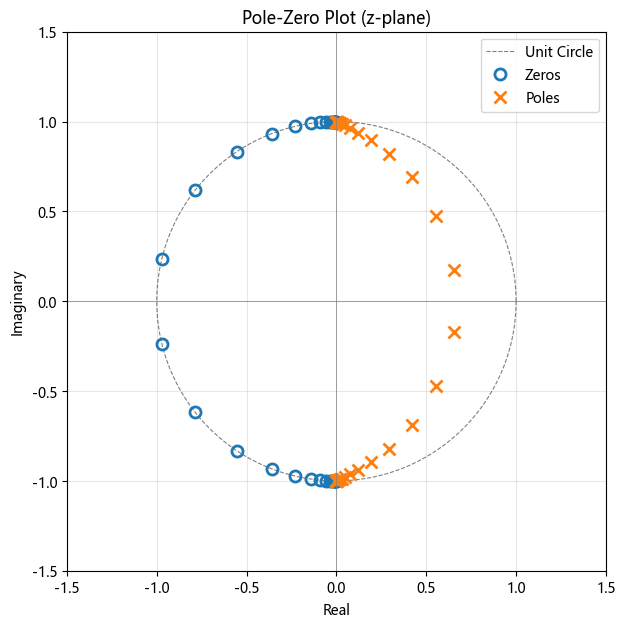

In [ ]:
zeros, poles, k = zpk
# 零极点图
fig, ax = plt.subplots(figsize=(7, 7))

# 绘制单位圆
theta = np.linspace(0, 2 * np.pi, 1000)
ax.plot(np.cos(theta), np.sin(theta), "k--", lw=0.8, alpha=0.5, label="Unit Circle")

# 绘制零点 (o) 和极点 (x)
ax.plot(
    np.real(zeros),
    np.imag(zeros),
    "o",
    color="C0",
    ms=8,
    mfc="none",
    mew=2,
    label="Zeros",
)
ax.plot(np.real(poles), np.imag(poles), "x", color="C1", ms=8, mew=2, label="Poles")

# 坐标轴装饰
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_aspect("equal")
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_xlabel("Real")
ax.set_ylabel("Imaginary")
ax.set_title("Pole-Zero Plot (z-plane)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## 遮盖法 (Cover-up Method) 转换到并行形式

除了 `scipy.signal.residuez`，还可以用**遮盖法**手动计算留数。对于 $H(z) = k \cdot \dfrac{\prod (z - z_j)}{\prod (z - p_i)}$，第 $i$ 个极点的留数为：

**z 域形式（对应 $z^{-1}/(1-pz^{-1})$ 节）：**

$$
r_i = k \cdot \frac{\prod_j (p_i - z_j)}{\prod_{j \neq i} (p_i - p_j)},\qquad d = k
$$

**z⁻¹ 域形式（对应 $1/(1-pz^{-1})$ 节）：**

$$
r_i = k \cdot \frac{\prod_j (1 - z_j/p_i)}{\prod_{j \neq i} (1 - p_j/p_i)},\qquad
d = k \cdot \frac{\prod_j (-z_j)}{\prod_j (-p_j)}
$$

> 本 notebook 后续主要使用 **z⁻¹ 域** 形式，因为希尔伯特变换的 $z \to -jz$ 替换在 $z^{-1}$ 下更直观。

In [ ]:
zeros, poles, k = zpk

# 以z=pole[i]进行遮盖法计算
residual_cover1 = []
for i in range(len(zeros)):
    z = poles[i]
    up = 1
    down = 1
    for j in range(len(zeros)):
        up *= z - zeros[j]
    for j in range(len(poles)):
        if i != j:
            down *= z - poles[j]
    residual_cover1.append(up / down)

residual_cover1 = np.array(residual_cover1)
direct_cover1 = 1

residual_cover1 = residual_cover1 * k
direct_cover1 = direct_cover1 * k

print(residual_cover1)
print(direct_cover1)

[ 1.79418068e-01+4.80977734e-01j -3.79293007e-01-2.19222590e-01j
  3.28019244e-01-3.53020404e-02j -1.78848705e-01+1.42701967e-01j
  5.67842567e-02-1.39999335e-01j  8.50983802e-03+9.65878833e-02j
 -3.12546519e-02-5.26089767e-02j  3.15159721e-02+2.15945983e-02j
 -2.33083586e-02-4.05587177e-03j  1.40517351e-02-3.71168754e-03j
 -6.76142352e-03+5.68446123e-03j  2.10305270e-03-4.83658404e-03j
  2.63052084e-04+3.03000720e-03j -9.68420036e-04-1.30566872e-03j
  6.87165195e-04+2.21490449e-04j -1.92579919e-04+5.57580978e-05j
  1.79418068e-01-4.80977734e-01j -3.79293007e-01+2.19222590e-01j
  3.28019244e-01+3.53020404e-02j -1.78848705e-01-1.42701967e-01j
  5.67842567e-02+1.39999335e-01j  8.50983802e-03-9.65878833e-02j
 -3.12546519e-02+5.26089767e-02j  3.15159721e-02-2.15945983e-02j
 -2.33083586e-02+4.05587177e-03j  1.40517351e-02+3.71168754e-03j
 -6.76142352e-03-5.68446123e-03j  2.10305270e-03+4.83658404e-03j
  2.63052084e-04-3.03000720e-03j -9.68420036e-04+1.30566872e-03j
  6.87165195e-04-2.214904

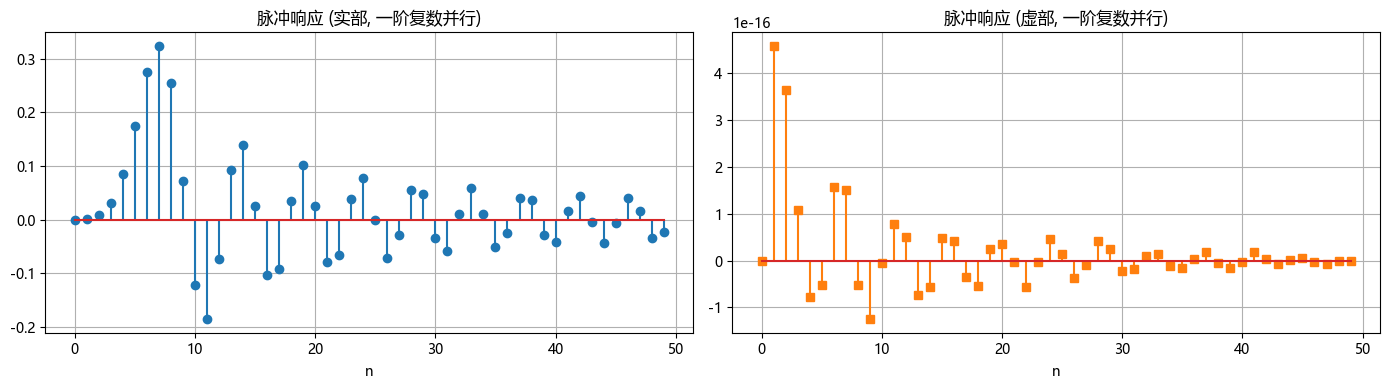

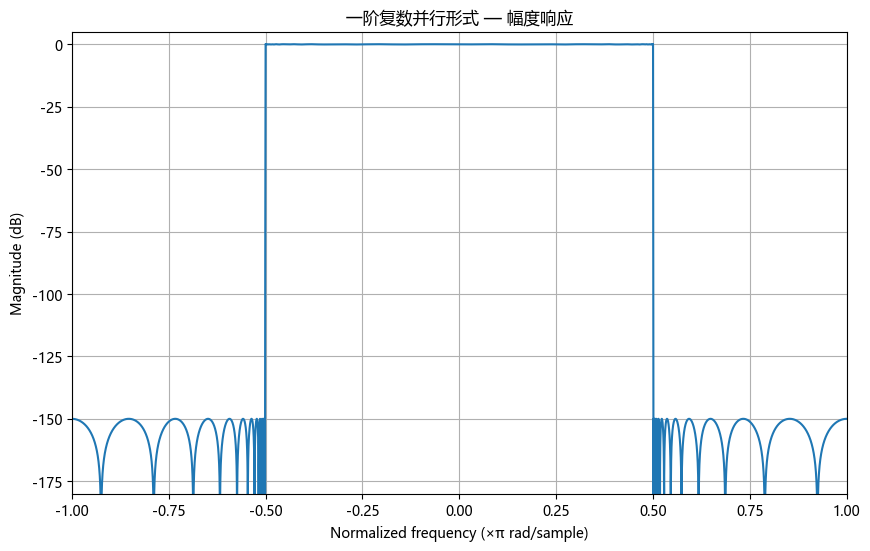

In [ ]:
# 使用 z⁻¹ 域遮盖法系数 (residual_cover2)，一阶复数形式计算脉冲响应和幅度响应
# H(z) = direct + Σ r / (1 - j·p·z⁻¹)

N_imp = 2**18
h_total = np.zeros(N_imp, dtype=complex)
h_total[0] = direct_cover1  # 直接项

for r, p in zip(residual_cover1, poles):
    h_total[1:] += r * p ** np.arange(N_imp - 1)

# 脉冲响应
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
n_ax = np.arange(N_imp)

axes[0].stem(
    n_ax[:50], np.real(h_total[:50]), linefmt="C0-", markerfmt="C0o", label="实部"
)
axes[0].set_title("脉冲响应 (实部, 一阶复数并行)")
axes[0].set_xlabel("n")
axes[0].grid()

axes[1].stem(
    n_ax[:50], np.imag(h_total[:50]), linefmt="C1-", markerfmt="C1s", label="虚部"
)
axes[1].set_title("脉冲响应 (虚部, 一阶复数并行)")
axes[1].set_xlabel("n")
axes[1].grid()

plt.tight_layout()
plt.show()

# FFT → 幅度响应
H = np.fft.fft(h_total)
H = np.fft.fftshift(H)
w_axis = np.fft.fftshift(np.fft.fftfreq(len(h_total))) * 2 * np.pi

mag_db = 20 * np.log10(np.abs(H) + 1e-15)

plt.figure(figsize=(10, 6))
plt.plot(w_axis / np.pi, mag_db)
plt.title("一阶复数并行形式 — 幅度响应")
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.ylim(-180, 5)
plt.xlim(-1, 1)
plt.show()


In [ ]:
zeros, poles, k = zpk
N = len(poles)

residual_cover2 = np.zeros(N, dtype=complex)
for i in range(N):
    z = poles[i]
    up = 1.0
    down = 1.0
    for j in range(N):
        up *= 1.0 - zeros[j] / z  # (1 - z_j/p_i)
    for j in range(N):
        if i != j:
            down *= 1.0 - poles[j] / z  # (1 - p_j/p_i)
    residual_cover2[i] = k * up / down

# z^-1 -> inf
# 那就是 z -> 0
up = 1.0
down = 1.0
for i in range(N):
    up *= 0 - zeros[i]
for i in range(N):
    down *= 0 - poles[i]

direct_cover2 = k * np.real(up / down)

print(residual_cover2)
print(direct_cover2)

[ 7.55884597e-02+7.56884923e-01j -2.00147245e-01-5.64367386e-01j
  2.48870140e-01+3.24870140e-01j -2.23165709e-01-1.39092343e-01j
  1.62369901e-01+2.87350282e-02j -9.99813396e-02+2.20736531e-02j
  5.16808027e-02-3.65403342e-02j -2.04676934e-02+3.32104346e-02j
  3.41635662e-03-2.37214498e-02j  3.98747465e-03+1.40970213e-02j
 -5.78087322e-03-6.73668767e-03j  4.86296006e-03+2.08215124e-03j
 -3.03477491e-03+2.72240668e-04j  1.30586200e-03-9.71061198e-04j
 -2.21394270e-04+6.87615078e-04j -5.57499803e-05-1.92617889e-04j
  7.55884597e-02-7.56884923e-01j -2.00147245e-01+5.64367386e-01j
  2.48870140e-01-3.24870140e-01j -2.23165709e-01+1.39092343e-01j
  1.62369901e-01-2.87350282e-02j -9.99813396e-02-2.20736531e-02j
  5.16808027e-02+3.65403342e-02j -2.04676934e-02-3.32104346e-02j
  3.41635662e-03+2.37214498e-02j  3.98747465e-03-1.40970213e-02j
 -5.78087322e-03+6.73668767e-03j  4.86296006e-03-2.08215124e-03j
 -3.03477491e-03-2.72240668e-04j  1.30586200e-03+9.71061198e-04j
 -2.21394270e-04-6.876150

In [ ]:
a = []
b = []
c = []
d = []

for i in range(0, len(residual_cover2) // 2):
    p = poles[i]
    pdot = np.conj(p)
    r = residual_cover2[i]
    rdot = np.conj(r)

    a.append(np.real(r + rdot))
    b.append(np.real(r * pdot + rdot * p))
    c.append(np.real(p + pdot))
    d.append(np.real(p * pdot))

# Print a, b, c, d as C float arrays
for name, arr in [("a", a), ("b", b), ("c", c), ("d", d)]:
    print(f"static constexpr double {name}[{len(arr)}]{{")
    elements = ", ".join(f"{v:.10e}" for v in arr)
    print("    " + elements + ",};")
    print()
print(f"static constexpr double direct_ = {direct_cover2};")
print(f"static constexpr int kState = {order // 2};")

static constexpr double a[16]{
    1.5117691950e-01, -4.0029448985e-01, 4.9774027954e-01, -4.4633141833e-01, 3.2473980264e-01, -1.9996267924e-01, 1.0336160540e-01, -4.0935386859e-02, 6.8327132448e-03, 7.9749493092e-03, -1.1561746436e-02, 9.7259201265e-03, -6.0695498296e-03, 2.6117239910e-03, -4.4278853955e-04, -1.1149996062e-04,};

static constexpr double b[16]{
    -1.6150960039e-01, 3.1285144583e-01, -2.3897509472e-01, 9.8686295334e-02, 1.0576186212e-02, -6.5895779752e-02, 7.8355485382e-02, -6.6911037420e-02, 4.7011218501e-02, -2.7827970196e-02, 1.3290298175e-02, -4.0972773302e-03, -5.6086795657e-04, 1.9432727706e-03, -1.3746116533e-03, 3.8518024932e-04,};

static constexpr double c[16]{
    1.3052689240e+00, 1.1135166236e+00, 8.3791368666e-01, 5.8031118445e-01, 3.8228975485e-01, 2.4442612941e-01, 1.5330819938e-01, 9.4761364871e-02, 5.7737148988e-02, 3.4545671410e-02, 2.0113644317e-02, 1.1189489279e-02, 5.7275727638e-03, 2.4630086794e-03, 6.3520964134e-04, -1.8305928139e-04,};

stati

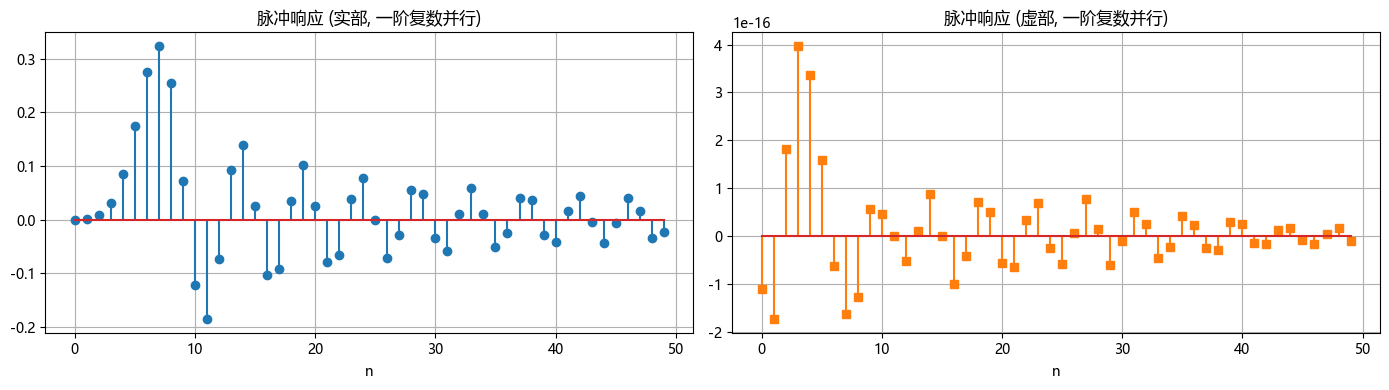

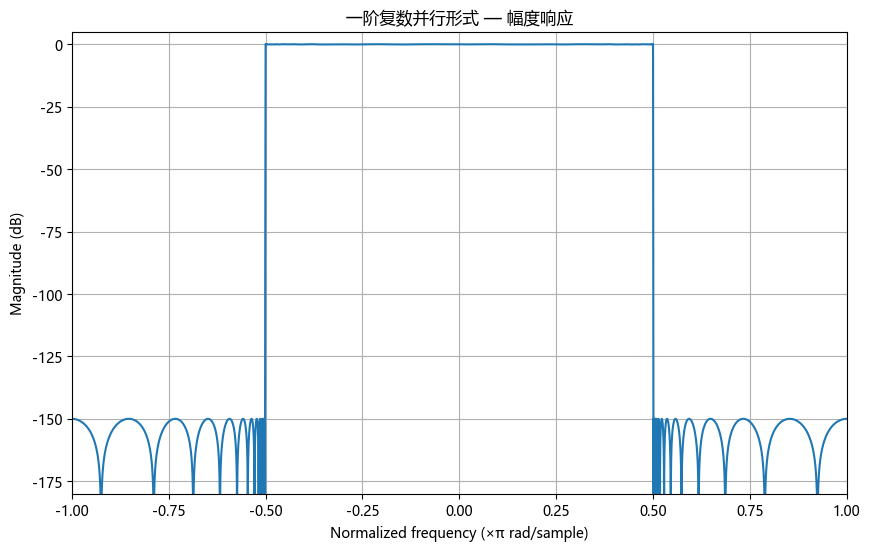

In [ ]:
# 使用 z⁻¹ 域遮盖法系数 (residual_cover2)，一阶复数形式计算脉冲响应和幅度响应
# H(z) = direct + Σ r / (1 - j·p·z⁻¹)

N_imp = 2**18
h_total = np.zeros(N_imp, dtype=complex)
h_total[0] = direct_cover2  # 直接项

for r, p in zip(residual_cover2, poles):
    h_total += r * p ** np.arange(N_imp)

# 脉冲响应
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
n_ax = np.arange(N_imp)

axes[0].stem(
    n_ax[:50], np.real(h_total[:50]), linefmt="C0-", markerfmt="C0o", label="实部"
)
axes[0].set_title("脉冲响应 (实部, 一阶复数并行)")
axes[0].set_xlabel("n")
axes[0].grid()

axes[1].stem(
    n_ax[:50], np.imag(h_total[:50]), linefmt="C1-", markerfmt="C1s", label="虚部"
)
axes[1].set_title("脉冲响应 (虚部, 一阶复数并行)")
axes[1].set_xlabel("n")
axes[1].grid()

plt.tight_layout()
plt.show()

# FFT → 幅度响应
H = np.fft.fft(h_total)
H = np.fft.fftshift(H)
w_axis = np.fft.fftshift(np.fft.fftfreq(len(h_total))) * 2 * np.pi

mag_db = 20 * np.log10(np.abs(H) + 1e-15)

plt.figure(figsize=(10, 6))
plt.plot(w_axis / np.pi, mag_db)
plt.title("一阶复数并行形式 — 幅度响应")
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.ylim(-180, 5)
plt.xlim(-1, 1)
plt.show()


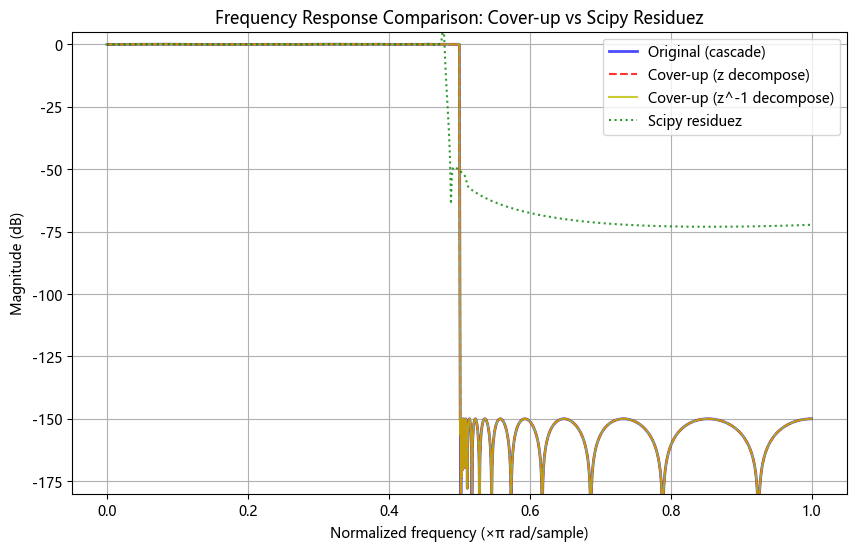

In [ ]:
# 验证: 两种并行形式 vs 原始级联形式
w_f, h_ref = signal.sosfreqz(sos, worN=4096)
z = np.exp(1j * w_f)

# z 遮盖法: z^-1/(1-p*z^-1) 形式
H_cover1 = direct_cover1 * np.ones_like(z)
for r, p in zip(residual_cover1, poles):
    H_cover1 += r * z**-1 / (1 - p * z**-1)

# ---

# z⁻¹ 域遮盖法: 1/(1-p*z⁻¹) 形式
H_cover2 = direct_cover2 * np.ones_like(z)
for r, p in zip(residual_cover2, poles):
    H_cover2 += r / (1 - p * z**-1)

# ---

b, a = signal.sos2tf(sos)
residues_py, poles_py, direct_term_py = signal.residuez(b, a)
# scipy residuez: 1/(1-p*z^-1) 形式
H_scipy = direct_term_py * np.ones_like(z)
for r, p in zip(residues_py, poles_py):
    H_scipy += r / (1 - p * z**-1)

# ---

plt.figure(figsize=(10, 6))
plt.plot(
    w_f / np.pi,
    20 * np.log10(np.abs(h_ref)),
    "b-",
    label="Original (cascade)",
    alpha=0.7,
    lw=2,
)
plt.plot(
    w_f / np.pi,
    20 * np.log10(np.abs(H_cover1)),
    "r--",
    label="Cover-up (z decompose)",
    alpha=0.8,
)
plt.plot(
    w_f / np.pi,
    20 * np.log10(np.abs(H_cover2)),
    "y",
    label="Cover-up (z^-1 decompose)",
    alpha=0.8,
)
plt.plot(
    w_f / np.pi, 20 * np.log10(np.abs(H_scipy)), "g:", label="Scipy residuez", alpha=0.8
)
plt.title("Frequency Response Comparison: Cover-up vs Scipy Residuez")
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.grid()
plt.ylim(-180, 5)
plt.show()

# 复数并行，共轭能不能消除

对于半带滤波器的并行形式，每对共轭复数的脉冲响应为：

$$
h_r[n] = r \cdot p^n, \quad h_{rc}[n] = \bar{r} \cdot \bar{p}^n
$$

由于 $h_{rc}[n] = \overline{h_r[n]}$，两者之和为：

$$
h_r[n] + h_{rc}[n] = 2 \cdot \text{Re}[r \cdot p^n]
$$

这是一个**纯实数**序列！这意味着我们可以丢掉复数运算，用单个实数二阶节来等效替代每对复数一阶节。

> 本节用第一对极点和留数验证这个等价关系。

r = (0.17941806771633903+0.48097773366260876j)
p = (0.6526344619972196-0.1718708221510049j)
Max difference: 0.00e+00


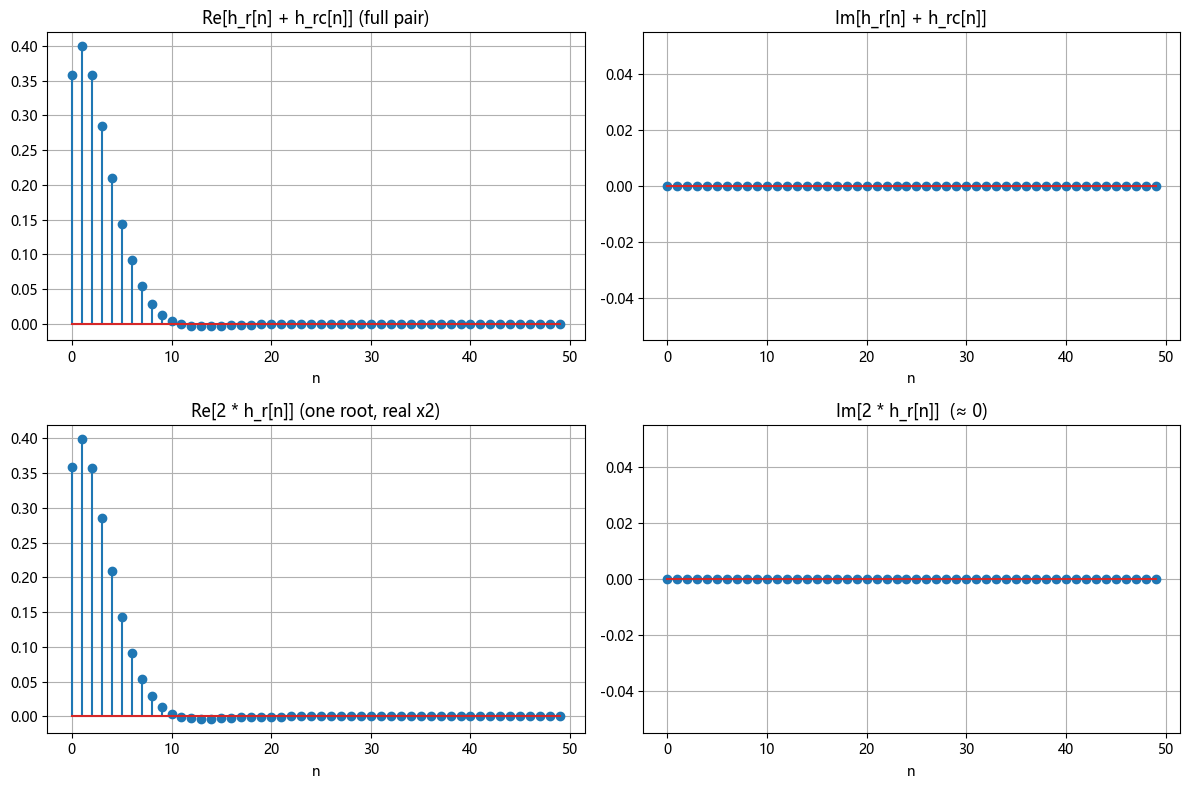

In [ ]:
r = residual_cover1[0]
p = poles[0]
rc = np.conj(r)
pc = np.conj(p)

n = np.arange(0, 50)
h_r = r * p**n  # single complex section
h_rc = rc * pc**n  # conjugate section
h_sum = h_r + h_rc  # full conjugate pair
h_realx2 = 2 * np.real(h_r)  # 2 * Re[r * p^n]

# Verify equivalence
print(f"r = {r}")
print(f"p = {p}")
print(f"Max difference: {np.max(np.abs(h_sum - h_realx2)):.2e}")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Conjugate pair: real part
axes[0, 0].stem(n, np.real(h_sum))
axes[0, 0].set_title("Re[h_r[n] + h_rc[n]] (full pair)")
axes[0, 0].set_xlabel("n")
axes[0, 0].grid()

# Conjugate pair: imaginary part
axes[0, 1].stem(n, np.imag(h_sum))
axes[0, 1].set_title("Im[h_r[n] + h_rc[n]]")
axes[0, 1].set_xlabel("n")
axes[0, 1].grid()

# 2 * Re[r * p^n]: real part
axes[1, 0].stem(n, np.real(h_realx2))
axes[1, 0].set_title("Re[2 * h_r[n]] (one root, real x2)")
axes[1, 0].set_xlabel("n")
axes[1, 0].grid()

# 2 * Re[r * p^n]: imaginary part
axes[1, 1].stem(n, np.imag(h_realx2))
axes[1, 1].set_title("Im[2 * h_r[n]]  (≈ 0)")
axes[1, 1].set_xlabel("n")
axes[1, 1].grid()

plt.tight_layout()
plt.show()

# 将半带滤波器转换到希尔伯特滤波器

通过频率偏移将半带低通变为希尔伯特变压器（全通、$\pm 90^\circ$ 相移）：

$$
H(z) \longrightarrow H(-jz) \quad \text{(频率偏移 $+\pi/2$)}
$$

等价于在 $z^{-1}$ 域做替换 $z^{-1} \to j z^{-1}$：

- 正向节：$\displaystyle \frac{r}{1 - p z^{-1}} \longrightarrow \frac{r}{1 - j p z^{-1}}$，脉冲响应 $r \cdot (j p)^n$
- 共轭节：$\displaystyle \frac{\bar{r}}{1 - \bar{p} z^{-1}} \longrightarrow \frac{\bar{r}}{1 - j \bar{p} z^{-1}}$，脉冲响应 $\bar{r} \cdot (j \bar{p})^n$

> 注意：两个支路都用了同样的替换 $z^{-1}\to jz^{-1}$（即 $H(z^{-1})\to H(jz^{-1})$），这会导致共轭关系被破坏。后续会验证这对求和结果的影响。

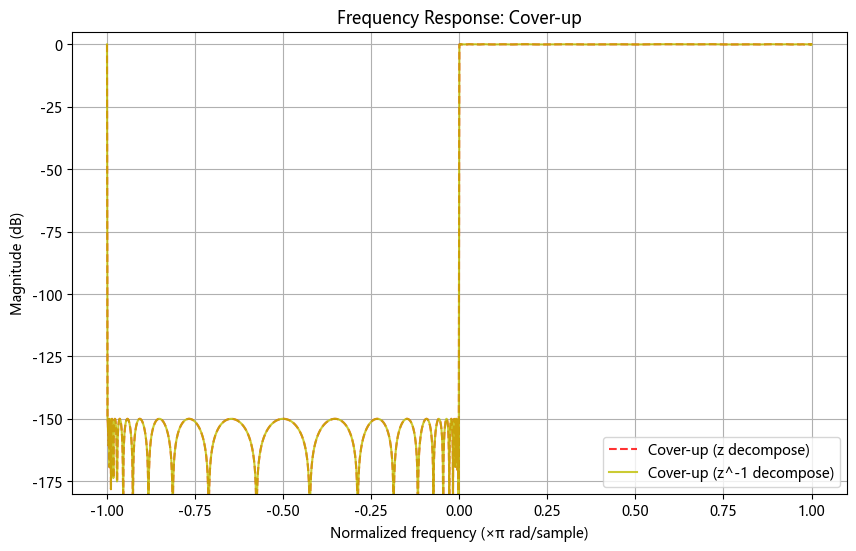

In [ ]:
# 验证: 两种并行形式 vs 原始级联形式
w_f = np.linspace(-np.pi, np.pi, 4096)
z = np.exp(1j * w_f)

# z 遮盖法: z^-1/(1-p*z^-1) 形式
H_cover1 = direct_cover1 * np.ones_like(z)
for r, p in zip(residual_cover1, poles):
    H_cover1 += r / (-1j * z - p)

# ---

# z⁻¹ 域遮盖法: 1/(1-p*z⁻¹) 形式
H_cover2 = direct_cover2 * np.ones_like(z)
for r, p in zip(residual_cover2, poles):
    H_cover2 += r / (1 - p * 1j * z**-1)

# ---

plt.figure(figsize=(10, 6))
plt.plot(
    w_f / np.pi,
    20 * np.log10(np.abs(H_cover1)),
    "r--",
    label="Cover-up (z decompose)",
    alpha=0.8,
)
plt.plot(
    w_f / np.pi,
    20 * np.log10(np.abs(H_cover2)),
    "y",
    label="Cover-up (z^-1 decompose)",
    alpha=0.8,
)
plt.title("Frequency Response: Cover-up")
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.legend()
plt.grid()
plt.ylim(-180, 5)
plt.show()

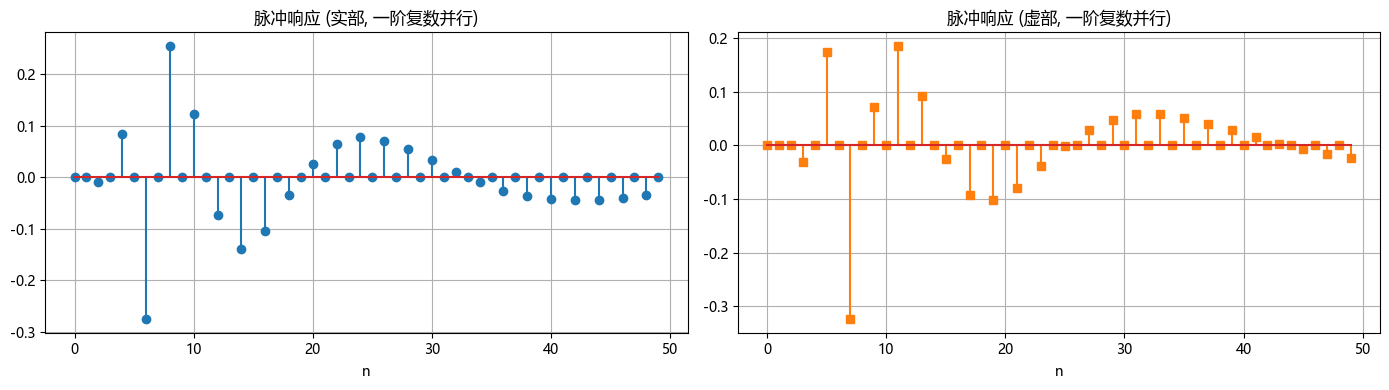

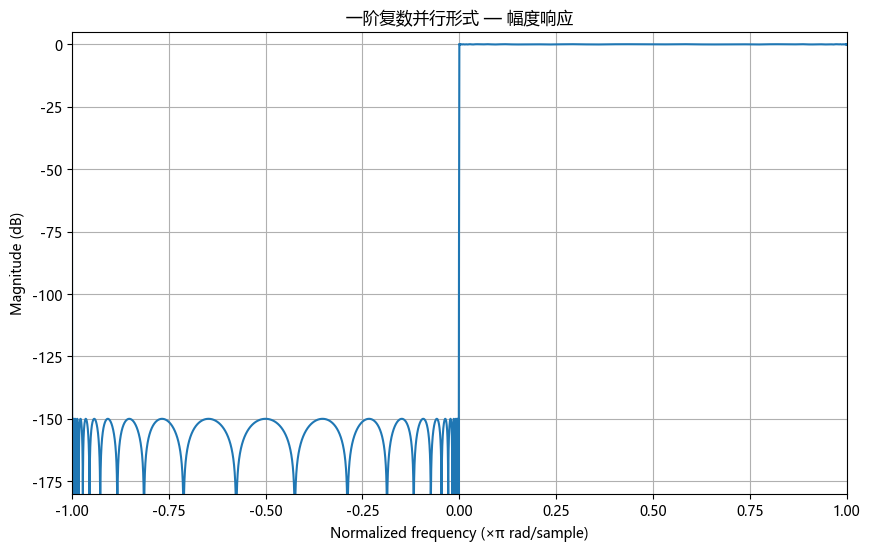

In [ ]:
# 使用 z⁻¹ 域遮盖法系数 (residual_cover2)，一阶复数形式计算脉冲响应和幅度响应
# H(z) = direct + Σ r / (1 - j·p·z⁻¹)

N_imp = 2**18
h_total = np.zeros(N_imp, dtype=complex)
h_total[0] = direct_cover2  # 直接项

for r, p in zip(residual_cover2, poles):
    h_total += r * (p * 1j) ** np.arange(N_imp)

# 脉冲响应
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
n_ax = np.arange(N_imp)

axes[0].stem(
    n_ax[:50], np.real(h_total[:50]), linefmt="C0-", markerfmt="C0o", label="实部"
)
axes[0].set_title("脉冲响应 (实部, 一阶复数并行)")
axes[0].set_xlabel("n")
axes[0].grid()

axes[1].stem(
    n_ax[:50], np.imag(h_total[:50]), linefmt="C1-", markerfmt="C1s", label="虚部"
)
axes[1].set_title("脉冲响应 (虚部, 一阶复数并行)")
axes[1].set_xlabel("n")
axes[1].grid()

plt.tight_layout()
plt.show()

# FFT → 幅度响应
H = np.fft.fft(h_total)
H = np.fft.fftshift(H)
w_axis = np.fft.fftshift(np.fft.fftfreq(len(h_total))) * 2 * np.pi

mag_db = 20 * np.log10(np.abs(H) + 1e-15)

plt.figure(figsize=(10, 6))
plt.plot(w_axis / np.pi, mag_db)
plt.title("一阶复数并行形式 — 幅度响应")
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.ylim(-180, 5)
plt.xlim(-1, 1)
plt.show()


# 希尔伯特滤波器的复数共轭能不能整合？

以 z⁻¹ 域分解（$1/(1-pz^{-1})$ 形式）为测试。希尔伯特变换后：

$$
H_h(z) = d + \sum \frac{r_i}{1 - j p_i z^{-1}}
$$

此时每对共轭节的脉冲响应为：

$$
h_r[n] = r \cdot (j p)^n, \quad h_{rc}[n] = \bar{r} \cdot (j \bar{p})^n
$$

但 $\overline{h_r[n]} = \bar{r} \cdot (-j \bar{p})^n \neq h_{rc}[n]$（差 $(-1)^n$ 因子），因此 $h_r + h_{rc}$ 不再像半带滤波器那样为纯实数，而是交替实/虚。

> 本节观察单个共轭对的脉冲响应形态，下一节尝试将其合并为复数二阶节。

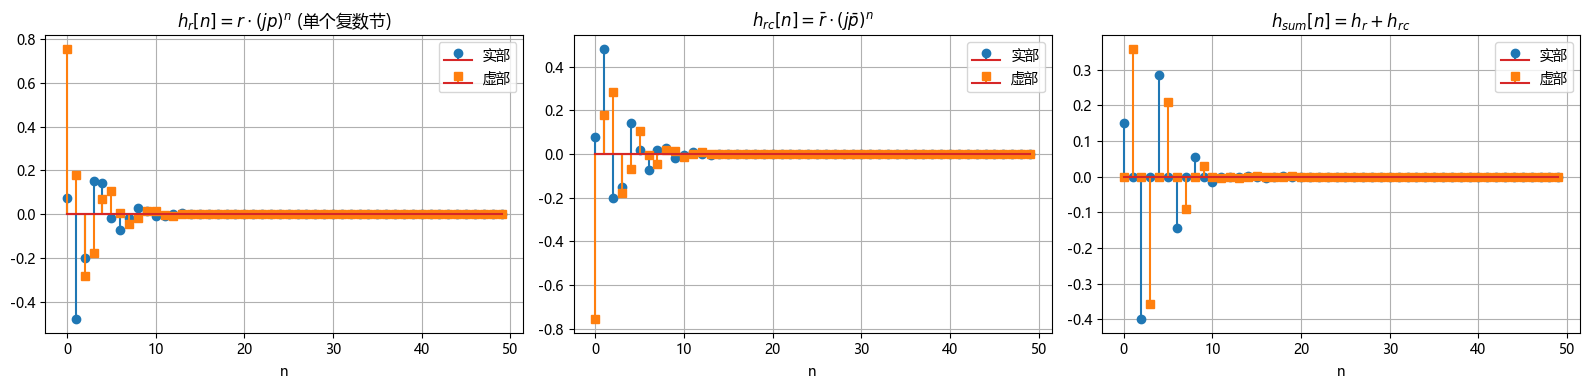

In [ ]:
r = residual_cover2[0]
p = poles[0]
rc = np.conj(r)
pc = np.conj(p)

n = np.arange(0, 50)
h_r = r * (p * 1j) ** n  # 单个复数节 (z⁻¹ → jz⁻¹)
h_rc = rc * (pc * 1j) ** n  # 另一个节
h_sum = h_r + h_rc  # 两者之和

# 绘图对比
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 第1列: h_r (单个复数节)
axes[0].stem(n, np.real(h_r), linefmt="C0-", markerfmt="C0o", label="实部")
axes[0].stem(n, np.imag(h_r), linefmt="C1-", markerfmt="C1s", label="虚部")
axes[0].set_title(r"$h_r[n] = r \cdot (j p)^n$ (单个复数节)")
axes[0].set_xlabel("n")
axes[0].legend()
axes[0].grid()

# 第2列: h_rc (另一个节)
axes[1].stem(n, np.real(h_rc), linefmt="C0-", markerfmt="C0o", label="实部")
axes[1].stem(n, np.imag(h_rc), linefmt="C1-", markerfmt="C1s", label="虚部")
axes[1].set_title(r"$h_{rc}[n] = \bar{r} \cdot (j \bar{p})^n$")
axes[1].set_xlabel("n")
axes[1].legend()
axes[1].grid()

# 第3列: h_sum (两者之和)
axes[2].stem(n, np.real(h_sum), linefmt="C0-", markerfmt="C0o", label="实部")
axes[2].stem(n, np.imag(h_sum), linefmt="C1-", markerfmt="C1s", label="虚部")
axes[2].set_title(r"$h_{sum}[n] = h_r + h_{rc}$")
axes[2].set_xlabel("n")
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()


二阶节系数:
  a = 1.5117691950e-01+0.0000000000e+00j
  b = 0.0000000000e+00+1.6150960039e-01j
  c = 0.0000000000e+00-1.3052689240e+00j
  d = -4.5547132049e-01+0.0000000000e+00j

与 h_r + h_rc 直接相加的差异: max|误差| = 1.39e-16


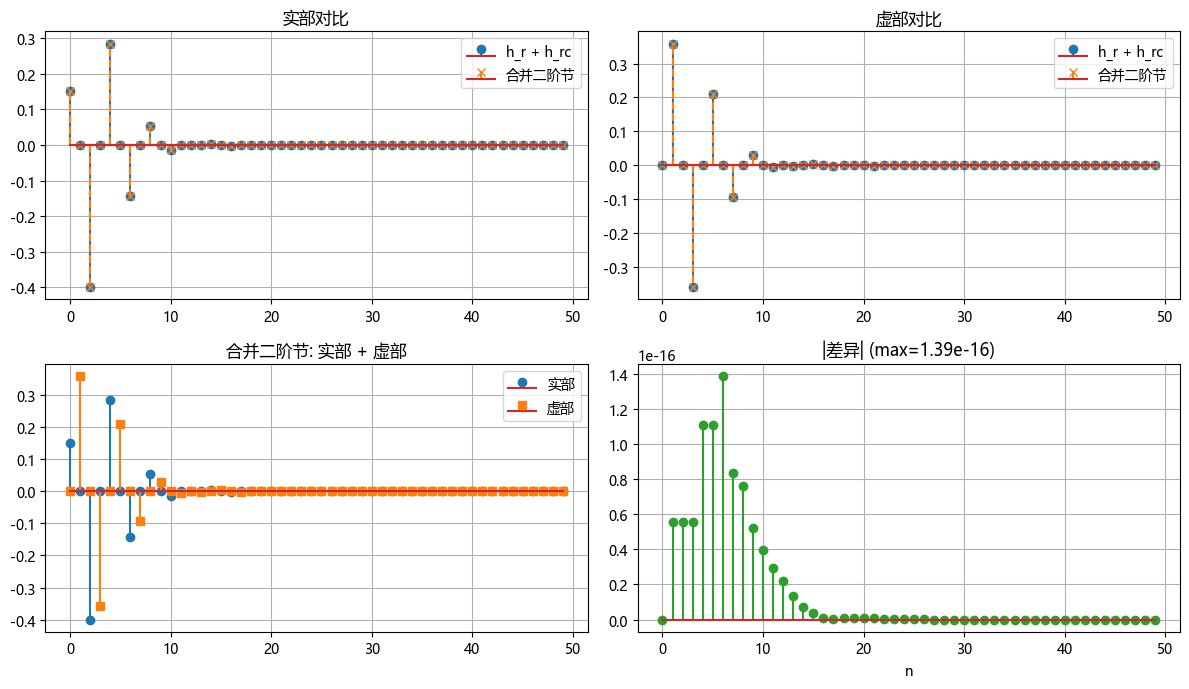

In [ ]:
# 将两个复数一阶节合并为单个复数二阶节，计算脉冲响应
# H(z) = r/(1-jp·z⁻¹) + r̅/(1-j·p̅·z⁻¹)
#      = (a + b·z⁻¹) / (1 + c·z⁻¹ + d·z⁻²)

r = residual_cover2[0]
p = poles[0]

# 二阶节系数
a = r + np.conj(r)  # 2*Re[r]
b = -1j * (r * np.conj(p) + np.conj(r) * p)
c = -1j * (p + np.conj(p))  # -2j*Re[p]
d = -p * np.conj(p)  # -|p|²

# 打印系数（确认是实数）
print("二阶节系数:")
print(f"  a = {a:.10e}")
print(f"  b = {b:.10e}")
print(f"  c = {c:.10e}")
print(f"  d = {d:.10e}")

# 递推计算脉冲响应 h[n] + c·h[n-1] + d·h[n-2] = a·δ[n] + b·δ[n-1]
N = 50
h_sos = np.zeros(N, dtype=complex)
h_sos[0] = a  # n = 0
h_sos[1] = b - c * h_sos[0]  # n = 1
for n in range(2, N):
    h_sos[n] = -c * h_sos[n - 1] - d * h_sos[n - 2]  # n ≥ 2

# 与直接相加的结果对比
h_sum = r * (p * 1j) ** np.arange(N) + np.conj(r) * (np.conj(p) * 1j) ** np.arange(N)

err = np.max(np.abs(h_sos - h_sum))
print(f"\n与 h_r + h_rc 直接相加的差异: max|误差| = {err:.2e}")

# 绘图对比
n_ax = np.arange(N)
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# 实部对比
axes[0, 0].stem(
    n_ax, np.real(h_sum), linefmt="C0-", markerfmt="C0o", label="h_r + h_rc"
)
axes[0, 0].stem(
    n_ax, np.real(h_sos), linefmt="C1--", markerfmt="C1x", label="合并二阶节"
)
axes[0, 0].set_title("实部对比")
axes[0, 0].legend()
axes[0, 0].grid()

# 虚部对比
axes[0, 1].stem(
    n_ax, np.imag(h_sum), linefmt="C0-", markerfmt="C0o", label="h_r + h_rc"
)
axes[0, 1].stem(
    n_ax, np.imag(h_sos), linefmt="C1--", markerfmt="C1x", label="合并二阶节"
)
axes[0, 1].set_title("虚部对比")
axes[0, 1].legend()
axes[0, 1].grid()

# 合并二阶节的完整脉冲响应（实部 + 虚部）
axes[1, 0].stem(n_ax, np.real(h_sos), linefmt="C0-", markerfmt="C0o", label="实部")
axes[1, 0].stem(n_ax, np.imag(h_sos), linefmt="C1-", markerfmt="C1s", label="虚部")
axes[1, 0].set_title("合并二阶节: 实部 + 虚部")
axes[1, 0].legend()
axes[1, 0].grid()

# 差异详情
axes[1, 1].stem(n_ax, np.abs(h_sos - h_sum), linefmt="C2-", markerfmt="C2o")
axes[1, 1].set_title(f"|差异| (max={err:.2e})")
axes[1, 1].set_xlabel("n")
axes[1, 1].grid()

plt.tight_layout()
plt.show()


# 最终：结合遮盖法与复数二阶节

将全部 z⁻¹ 域遮盖法系数（`residual_cover2`）转换为**复数二阶节并行形式**。

每对共轭节 $r/(1-jp z^{-1}) + \bar{r}/(1-j\bar{p} z^{-1})$ 合并为：

$$
\frac{a + b z^{-1}}{1 + c z^{-1} + d z^{-2}}
$$

其中：

$$
\begin{cases}
a = r + \bar{r} = 2\,\text{Re}[r] \\[2pt]
b = -j\,(r\bar{p} + \bar{r}p) \\[2pt]
c = -j\,(p + \bar{p}) = -2j\,\text{Re}[p] \\[2pt]
d = -p\bar{p} = -|p|^2
\end{cases}
$$

注意 $b, c$ 为纯虚数（因为 $-j \times \text{实数}$），$a, d$ 为实数。

> 这些系数将被导出为 C 数组，用于最终的 C++ 实现。

In [ ]:
# 将全部 z⁻¹ 域遮盖法系数 (residual_cover2) 转换为复数二阶节
# 每对: r/(1-jp·z⁻¹) + r̅/(1-j·p̅·z⁻¹)
#      = (a + b·z⁻¹) / (1 + c·z⁻¹ + d·z⁻²)

half = len(poles) // 2  # 32/2 = 16 对

a_arr = []
b_arr = []
c_arr = []
d_arr = []

for i in range(half):
    r = residual_cover2[i]
    p = poles[i]
    rc = np.conj(r)  # 共轭由 conj 计算
    pc = np.conj(p)

    # 复数二阶节系数
    ak = r + rc  # 2*Re[r] → 实数
    bk = -1j * (r * pc + rc * p)  # 纯虚数
    ck = -1j * (p + pc)  # 纯虚数
    dk = -p * pc  # -|p|² → 实数

    a_arr.append(ak)
    b_arr.append(bk)
    c_arr.append(ck)
    d_arr.append(dk)

极点-留数闭式 vs 一阶复数直接求和: max|误差| = 5.34e-16


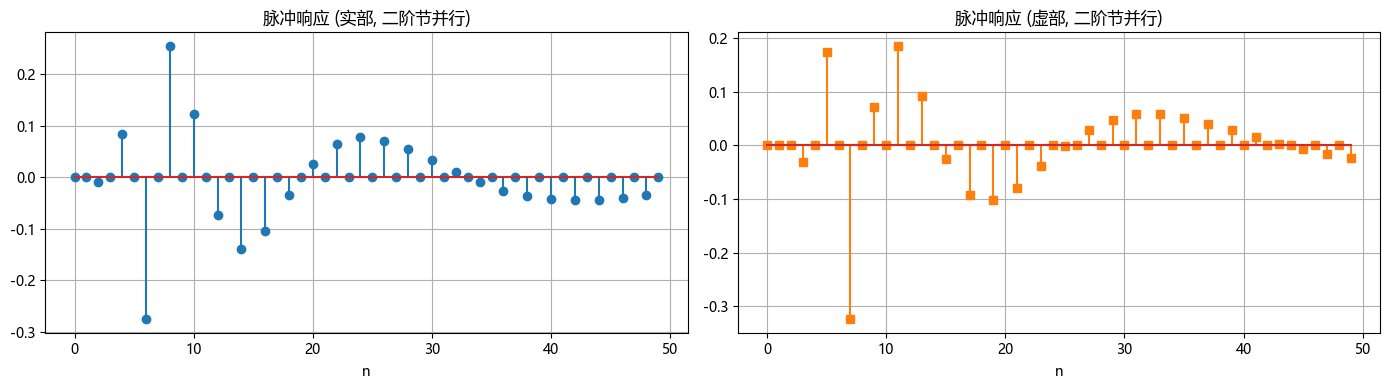

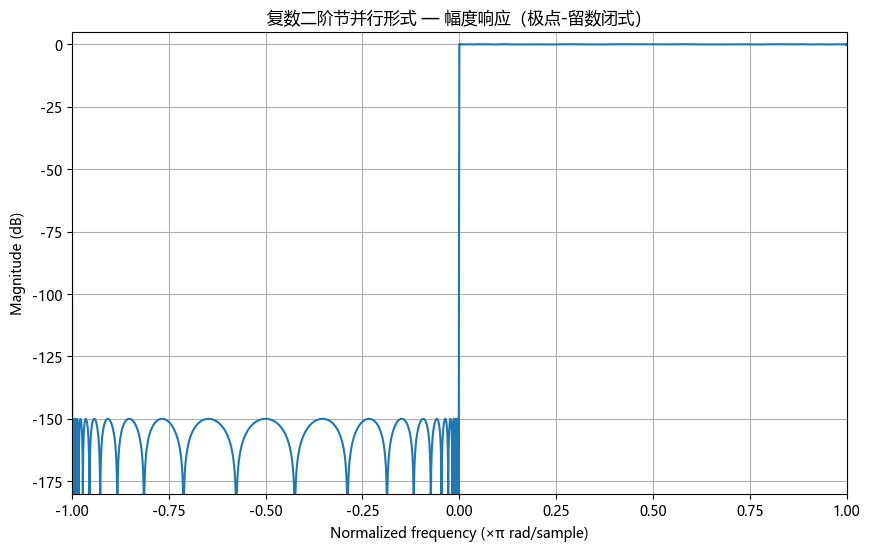

In [ ]:
# 使用极点-留数形式的闭式公式计算复数二阶节脉冲响应


def sos_impulse(a, b, c, d, N):
    """H(z) = (a + b·z⁻¹) / (1 + c·z⁻¹ + d·z⁻²) 的脉冲响应
    用极点-留数形式: h[n] = r1·p1ⁿ + r2·p2ⁿ
    """
    sqrt_d = np.sqrt(c**2 - 4 * d)
    p1 = (-c + sqrt_d) / 2  # 极点 1
    p2 = (-c - sqrt_d) / 2  # 极点 2

    # 留数: r = (a·p + b) / (p - q)
    r1 = (a * p1 + b) / (p1 - p2)
    r2 = (a * p2 + b) / (p2 - p1)

    n = np.arange(N)
    return r1 * p1**n + r2 * p2**n


# 构建总脉冲响应
N_imp = 2**18
h_total = np.zeros(N_imp, dtype=complex)
h_total[0] = direct_cover2  # 直接项

for i in range(half):
    h_total += sos_impulse(a_arr[i], b_arr[i], c_arr[i], d_arr[i], N_imp)

# 验证：与一阶复数形式对比
h_ref = np.zeros(N_imp, dtype=complex)
h_ref[0] = direct_cover2
for r, p in zip(residual_cover2, poles):
    h_ref += r * (p * 1j) ** np.arange(N_imp)

err = np.max(np.abs(h_total - h_ref))
print(f"极点-留数闭式 vs 一阶复数直接求和: max|误差| = {err:.2e}")

# 脉冲响应（前 50 点）
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
n_ax = np.arange(50)

axes[0].stem(n_ax, np.real(h_total[:50]), linefmt="C0-", markerfmt="C0o", label="实部")
axes[0].set_title("脉冲响应 (实部, 二阶节并行)")
axes[0].set_xlabel("n")
axes[0].grid()

axes[1].stem(n_ax, np.imag(h_total[:50]), linefmt="C1-", markerfmt="C1s", label="虚部")
axes[1].set_title("脉冲响应 (虚部, 二阶节并行)")
axes[1].set_xlabel("n")
axes[1].grid()

plt.tight_layout()
plt.show()

# FFT → 幅度响应
H = np.fft.fft(h_total)
H = np.fft.fftshift(H)
w_axis = np.fft.fftshift(np.fft.fftfreq(len(h_total))) * 2 * np.pi

mag_db = 20 * np.log10(np.abs(H) + 1e-15)

plt.figure(figsize=(10, 6))
plt.plot(w_axis / np.pi, mag_db)
plt.title("复数二阶节并行形式 — 幅度响应（极点-留数闭式）")
plt.xlabel("Normalized frequency (×π rad/sample)")
plt.ylabel("Magnitude (dB)")
plt.grid()
plt.ylim(-180, 5)
plt.xlim(-1, 1)
plt.show()